# Tasca S10.01. Analítica de dades en Pandas

*Descripció *

En aquesta tasca t’enfrontaràs a un exercici de neteja i analítica de dades.

Tenim un dataset provinent d’una enquesta als nostres treballadors i treballadors, i hem de garantir que les dades es processes correctament, tant en format com en llegibilitat.

In [ ]:
import pandas as pd
import numpy as np
import pprint
import matplotlib.pyplot as plt
import seaborn as sns

## Nivell 1

### 1
* Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

In [218]:
datafr = pd.read_excel("sprint10.xlsx", skiprows=3, header=0)

* Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.
* Mostra les primeres 10 files.

In [219]:
datafr.sort_values(["País d'origen", "Ciutat"]).iloc[0:10]

,Unnamed: 0,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B



* Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [220]:
# Checking if number of unique DNI values is not different than the number of rows in the dataframe.
print("No duplicates") if len(datafr["DNI"].unique()) == len(datafr) else print("There are duplicates")
# print(datafr.columns.duplicated())
# print(datafr["Gènere"].unique())

No duplicates


### 2.
* Crea una columna que sigui el nom complet.

In [221]:
datafr["Nom_Cognom"] = datafr["Nom"] + " " + datafr["Cognoms"]

* Crea una columna si la persona és nascuda a Espanya o no.

In [222]:
datafr["Nascuda_Espanya"] = np.where(datafr["País d'origen"] == 'Espanya', "Si", "No")

* Posa el DNI com a índex del DataFrame (noms de files).

In [223]:
datafr.set_index("DNI", inplace=True)

* Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.

In [224]:
datafr.rename(columns = {"Dia de Naixement": "Dia", "Mes de Naixement": "Mes", "Any de Naixement": "Any"}, inplace=True)

* Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

In [225]:
datafr["Gènere"] = datafr["Gènere"].replace({"H": "Home", "D": "Dona", "A": "Altres", "NC": pd.NA})

Mostra tots els canvis que has realitzat en una sola taula.

In [226]:
# to see dataframe fields and data types after the changes
print(datafr.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 16928694K to 89253307W
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1000 non-null   int64  
 1   Nom                1000 non-null   object 
 2   Cognoms            1000 non-null   object 
 3   País d'origen      1000 non-null   object 
 4   Ciutat             1000 non-null   object 
 5   Dia                1000 non-null   int64  
 6   Mes                1000 non-null   int64  
 7   Any                1000 non-null   int64  
 8   Gènere             940 non-null    object 
 9   Salari mensual     1000 non-null   object 
 10  Fills              406 non-null    float64
 11  No Fills           594 non-null    float64
 12  Grup Professional  1000 non-null   object 
 13  Nom_Cognom         1000 non-null   object 
 14  Nascuda_Espanya    1000 non-null   object 
dtypes: float64(2), int64(4), object(9)
memory usage: 125.0+ KB
None


In [ ]:
# to check how first several rows look like after the changes
print(datafr.head(3))

           Unnamed: 0     Nom           Cognoms País d'origen     Ciutat  Dia  \
DNI                                                                             
16928694K           0    Inês    Ferreira Silva      Portugal     Lisboa   25   
27724652S           1   Clara  Sánchez Martínez       Espanya  Barcelona   18   
38141675A           2  Fatima             Fassi        Marroc      Rabat    6   

           Mes   Any  Gènere  Salari mensual Fills  No Fills  \
DNI                                                            
16928694K    2  1953    Dona          1144.0    No       1.0   
27724652S    3  1996    Dona          1253.0    Si       NaN   
38141675A   11  2005  Altres          1441.0    Si       NaN   

          Grup Professional              Nom_Cognom Nascuda_Espanya  
DNI                                                                  
16928694K            Grup B     Inês Ferreira Silva              No  
27724652S            Grup A  Clara Sánchez Martínez            

### 3.
* Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [209]:
datafr["Fills"] = datafr["Fills"].apply(lambda x: 'Si' if x == 1.0 else 'No')

### 4.
* Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.
* Ordena la taula en funció del sou mig.

In [229]:
# Convert currency into numeric values
datafr["Salari mensual"] = datafr["Salari mensual"].str.replace("€", "").str.replace(".", "").astype(float)

# susing groupby make necessary calculations of Mean, Median, Minimal and Maximal salary and store as a dataframe with a single column. Modify column names correspondingly
Salari_mig = pd.DataFrame(datafr.groupby("Gènere")["Salari mensual"].mean().round(1))
Salari_mig.rename(columns = {"Salari mensual": "Salari mig"}, inplace=True)

Salari_media = pd.DataFrame(datafr.groupby("Gènere")["Salari mensual"].median())
Salari_media.rename(columns = {"Salari mensual": "Salari medià"}, inplace=True)

Salari_minim = pd.DataFrame(datafr.groupby("Gènere")["Salari mensual"].min())
Salari_minim.rename(columns = {"Salari mensual": "Salari mínim"}, inplace=True)

Salari_maxim = pd.DataFrame(datafr.groupby("Gènere")["Salari mensual"].max())
Salari_maxim.rename(columns = {"Salari mensual": "Salari màxim"}, inplace=True)

#merge all dataframes in one, with corresponding column names
Salari_mig.merge(Salari_media, left_index=True, right_index=True).merge(Salari_minim, left_index=True, right_index=True).merge(Salari_maxim, left_index=True, right_index=True).sort_values("Salari mig")

,Salari mig,Salari medià,Salari mínim,Salari màxim
Gènere,,,,
Dona,1469.4,1361.5,665.0,3021.0
Altres,1626.6,1545.0,703.0,3175.0
Home,1643.2,1531.0,737.0,3356.0


In [ ]:
#Alternatively similar result ca be achieved using '.agg' method to apply statistical functions for each of 'groupby' categories and column renaming
datafr.groupby("Gènere")["Salari mensual"].agg([
        ('mig', 'mean'),
        ('media', 'median'), 
        ('min', 'min'),
        ('max', 'max')
    ]).round(1).rename(columns={
        'mig': 'Salari mig',
        'media': 'Salari medià', 
        'min': 'Salari mínim',
        'max': 'Salari màxim'
    }).sort_values("Salari mig")

,Salari mig,Salari medià,Salari mínim,Salari màxim
Gènere,,,,
Dona,1469.4,1361.5,665.0,3021.0
Altres,1626.6,1545.0,703.0,3175.0
Home,1643.2,1531.0,737.0,3356.0


### 5.
* Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).
* Afegeix-hi les mitjanes als marges de la taula.

In [212]:
pd.DataFrame(datafr.groupby(["País d'origen", "Gènere"])["Salari mensual"].mean().round(1))

Salari mensual
País d'origen Gènere                
Alemanya      Altres           951.0
              Dona            1804.3
              Home            2067.4
Argentina     Altres          1141.0
              Dona            1291.8
              Home            1583.3
Colòmbia      Altres          1030.0
              Dona            1497.8
              Home            1554.7
Espanya       Altres          1706.2
              Dona            1460.2
              Home            1682.1
França        Dona            1566.5
              Home            1389.2
Itàlia        Altres          1423.0
              Dona            1247.2
              Home            1672.9
Marroc        Altres          1365.0
              Dona            1405.2
              Home            1531.0
Mèxic         Altres          1372.0
              Dona            1517.8
              Home            1625.0
Portugal      Altres          1765.0
              Dona            1488.5
              Home            1497.0
Regne Unit    Altres          1921.0
              Dona            1489.5
              Home            1162.6

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [ ]:
datafr[["País d'origen", "Gènere", "Salari mensual"]].pivot_table(index = "Gènere", columns = "País d'origen", aggfunc="mean", ).style.format('{:.1f}', na_rep='-').highlight_max(color = "green")

### 6.
* Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.
* Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [ ]:
#Create new column "Data de naixament" with the values created by pasting value from column "Dia", "Mes", "Any"
datafr["Data de naixament"] = pd.to_datetime(datafr["Dia"].astype(str) + "-" + datafr["Mes"].astype(str) + "-" + datafr["Any"].astype(str), dayfirst=True)

#Create the function to calculate the age using birth date and current date, using provided column name in a dataframe.
def fecha2Edad(dataframe, column):
    return [int((pd.Timestamp.today() - datafr[column].iloc[x])/pd.Timedelta(days=365.5)) for x in range(len(datafr))]

#Save the resul of age calculation into "Edat" column
datafr["Edat"] = fecha2Edad(datafr, "Data de naixament")

In [42]:
print(datafr.head())

           Unnamed: 0      Nom           Cognoms País d'origen     Ciutat  \
DNI                                                                         
16928694K           0     Inês    Ferreira Silva      Portugal     Lisboa   
27724652S           1    Clara  Sánchez Martínez       Espanya  Barcelona   
38141675A           2   Fatima             Fassi        Marroc      Rabat   
59157262R           3  Khadija   Bennani Bennani        Marroc      Rabat   
69630528M           4     Toni    Sánchez García       Espanya  Barcelona   

           Dia  Mes   Any  Gènere  Salari mensual Fills  No Fills  \
DNI                                                                 
16928694K   25    2  1953    Dona          1144.0    No       1.0   
27724652S   18    3  1996    Dona          1253.0    Si       NaN   
38141675A    6   11  2005  Altres          1441.0    Si       NaN   
59157262R   20    1  1995    Dona          1944.0    No       1.0   
69630528M    9    8  1999    Home          104

## Nivell 2

### 1.
* Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

* Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":
["5%","3,5%","2%","8%"]})

In [ ]:
df_increment = pd.DataFrame({"Grup": ["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})

# Set group names as indices to be able to call corresponding % value in "Increment"
df_increment.set_index("Grup", inplace=True)
# As % values are strings, have to convert them to decimals for further usage
percIncrement = df_increment["Increment"].map(lambda x: 1 + float(x.replace("%", "").replace(",", "."))/100)
#Update values in "Salari mensual" with increamented values
datafr["Salari mensual"] = datafr["Salari mensual"] * [percIncrement.loc[gr] for gr in datafr["Grup Professional"]]

### 2.
Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

In [ ]:
# Create iteratively dataframes 'gr' and save to CSV using 'key' parameter for dynamic naming of each saved CSV file
for key, gr in datafr.groupby("Grup Professional"):
    gr.to_csv(f'dades_{key.replace(" ", "")}.csv', index=False)

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [ ]:
# Create a dataframe of grouped values based on "Grup Professional" and applying "size", 'mean' and 'median' aggregating functions, and convert to CSV file saving
datafr.groupby("Grup Professional").agg(
    Nombre_treballadors = ("Grup Professional", 'size'),
    Salari_mig = ("Salari mensual", 'mean'),
    Edat_mediana = ("Edat", 'median')
).round(1).to_csv(f'Datos por Grup Professional.csv', index=True)

## Nivell 3
El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

### 1.
Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

un histograma/boxplot si la variable és numèrica
unes barres dels valors més freqüents si és categòrica
unes barres dels anys més freqüents si la dada està en format data.
La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

In [ ]:
#loading testing dataframes
iris_df = sns.load_dataset("iris")
titanic_df = sns.load_dataset("titanic")
penguins_df = sns.load_dataset("penguins")

In [ ]:
def plotting_function(dataframe):
    try:
        #check if dataframe was provided and it has at least one column length
        if isinstance(dataframe, pd.DataFrame) and len(dataframe.columns) >= 1:
            # checking each column for the number of unique values. If (0,1) is found, converted to BOOLEAN
            for c in dataframe.columns:
                if dataframe[c].isin([0,1]).all():
                    dataframe[c] = [True if val == 1 else False for val in dataframe[c]]
                # If the number of unique values does not comply with previous condition, check for the number of unique values and consider them as categories    
                elif len(dataframe[c].unique()) < 10:
                    dataframe[c] = dataframe[c].astype('category')
            # Analyse the type of each column in the dataframe to decide which type of plot to use.
                # If the type is 'float64' or 'int64' - it is quantitative and a Histogram plot is elaborated
            for col in dataframe.select_dtypes(include=['float64', 'int64']).columns:
                param = col.replace("_", " ").capitalize()
                title = f"Variability of {param} parameter"
                sns.histplot(data = dataframe, x=col)
                plt.title(title)
                plt.xlabel(param)
                plt.ylabel("Number of cases")
                plt.show()
                # If the type is 'object', 'bool', 'category' or 'datetime64' - it is qualitative / categorical and a Countplot representation is elaborated
            for col in dataframe.select_dtypes(include=['object', 'bool', 'category', 'datetime64']).columns:
                param = col.replace("_", " ").capitalize()
                title = f"Frequency of {param} categories"
                sns.countplot(data=dataframe, x=col, width = 0.5, edgecolor = "black")
                plt.title(title)
                plt.xlabel(param)
                plt.ylabel("Number of cases")
                plt.show()
        else:
             print("Dataframe is empty")
    except ValueError:
         print("Wrong object was provided, not a Dataframe")
    return


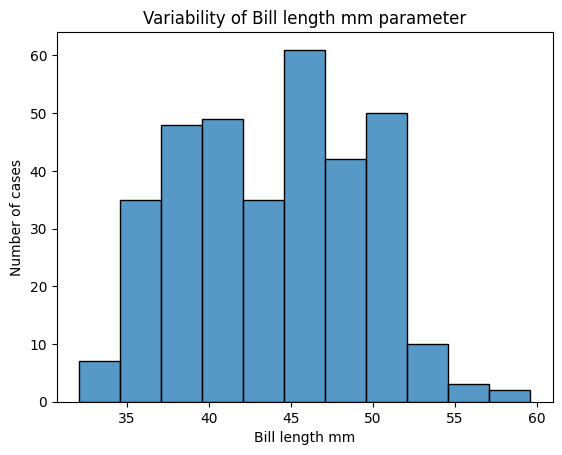

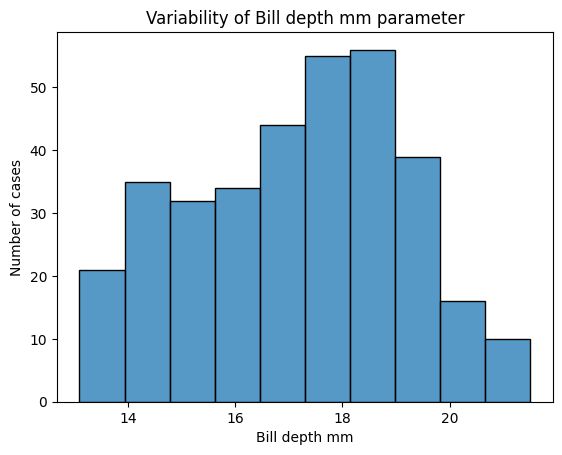

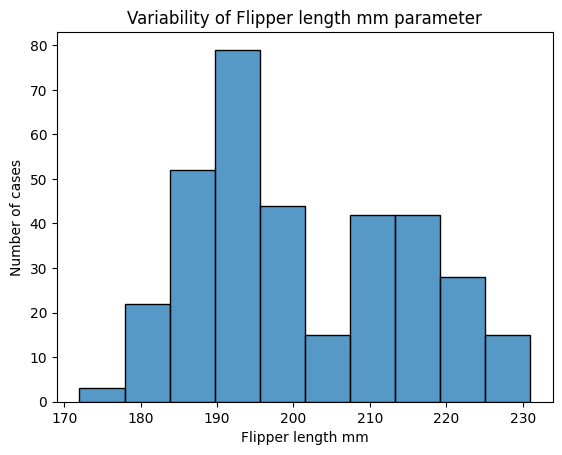

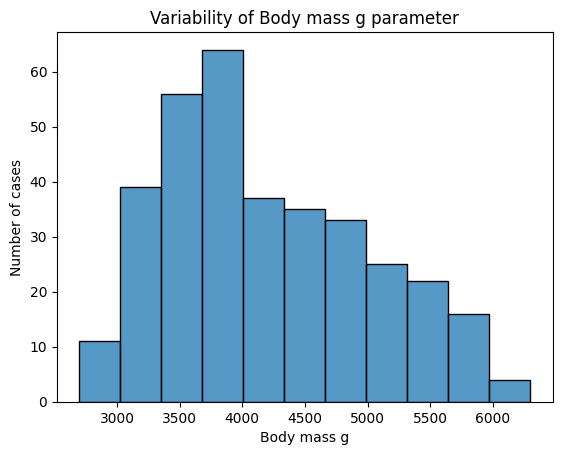

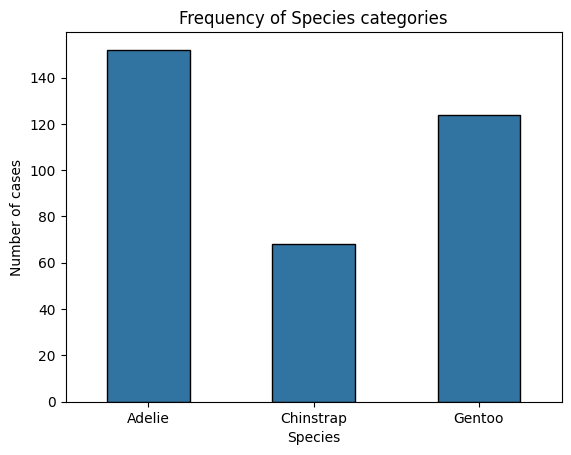

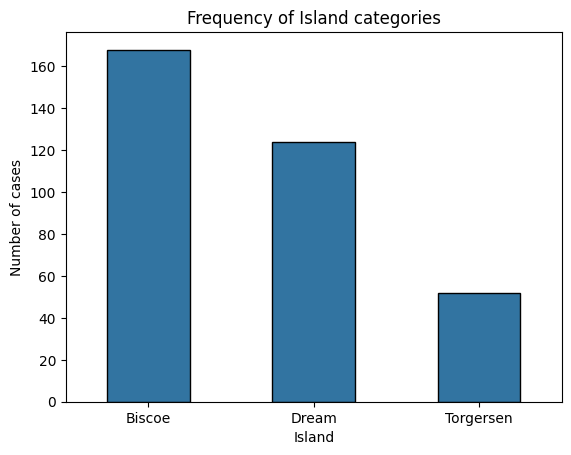

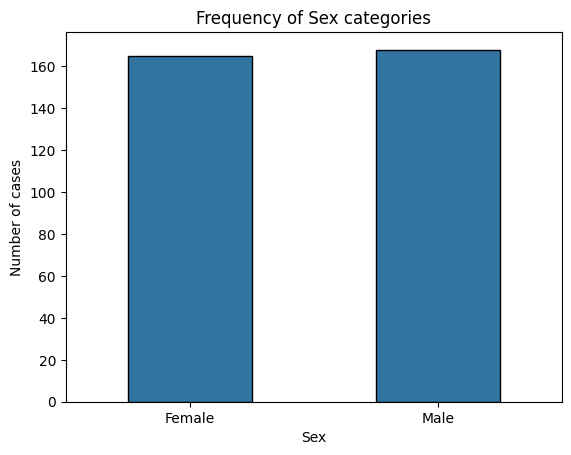

None


In [ ]:
print(plotting_function(penguins_df))
#print(plotting_function(iris_df))
#print(plotting_function(titanic_df))

### 2.
Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: Mejores Rutas

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

In [ ]:
# load distant matrix
matr_distancies = pd.read_excel("matriu_distancies.xlsx", index_col=0)
# replace missing values with NA
matr_distancies.fillna(pd.NA, inplace=True)
# pick the list of cities from the matrix
listaCiudades = list(matr_distancies.columns.sort_values())

['Alicante', 'Barcelona', 'Bilbao', 'Córdoba', 'Gijón', 'Hospitalet de Llobregat', 'Las Palmas de Gran Canaria', 'Murcia', 'Málaga', 'Palma', 'Sevilla', 'Valencia', 'Valladolid', 'Vigo', 'Zaragoza']


In [170]:
def route_estimation(matrDistancies, City=None, returnRoute=True, returnDistance=True, verbose=True):
    """Este funccio te ajuda a elaborar la ruta mas corta entre los seguentes ciutats:
    Alicante, Barcelona, Bilbao, Córdoba, Gijón, Hospitalet de Llobregat, Las Palmas de Gran Canaria, 
    Málaga, Murcia, Palma, Sevilla, Valencia, Valladolid, Vigo, Zaragoza.
    Elige una ciutat para empezar tu viaje."""
    # in case of a list of cities passed to the function, it is better to desactivate docstring, as it will repeat at each iteration
    if verbose:
        print(route_estimation.__doc__)
    
    # option to introduce city name if it was not provided as function parameter
        # might be not the best idea, to keep parametric declaration form for this function.
    if not City:
        City = str(input("Introduce the city you would like to start your trip"))
    
    #setting up Start City (for explicity), route and distance 
    route = [City]
    distance = 0
    
    #apply melting approach to analyse distance matrix
    matrDistancies = matrDistancies.reset_index()
    matrDistancies_melted = matrDistancies.melt(id_vars = 'index', value_vars=matr_distancies.columns)
    matrDistancies_melted.columns = ["Start", "End", "Distance"]

    #iteratively check the nearest city to Start City, identifying minimal distance, the index (endIndex) of neighbour city and it's name.
        # once identified, remove all rows where one of these cities is recorded in both "Start" and "End" columns.
    for i in range(len(matrDistancies_melted["Start"].unique())-1):
        startCity = route[-1]
        distance += float(matrDistancies_melted[matrDistancies_melted["Start"] == startCity]["Distance"].min())
        endIndex = matrDistancies_melted[matrDistancies_melted["Start"] == startCity]["Distance"].idxmin()
        route.append(matrDistancies_melted["End"].loc[endIndex])
        matrDistancies_melted = matrDistancies_melted.loc[~ (matrDistancies_melted["Start"] == startCity)]
        matrDistancies_melted = matrDistancies_melted.loc[~ (matrDistancies_melted["End"] == startCity)]

    # apply several options of resulting object 'proposed_route', depending on what is asked to demonstrate: the Route only, Distance only, or both
    match returnRoute, returnDistance:
        case True, True:
            proposed_route = {
                "Start City": City,
                "Ruta determinada": route,
                "Distancia estimada": f"{distance} km"
            }
        case True, False:
            proposed_route = {
                "Start City": City,
                "Ruta determinada": route
            }
        case False, True:
            proposed_route = (City, f"{distance} km")
    
    return proposed_route


In [171]:
pprint.pprint(route_estimation(matr_distancies, City="Vigo", returnRoute=True, returnDistance=True, verbose=True), compact=True, sort_dicts=False)

Este funccio te ajuda a elaborar la ruta mas corta entre los seguentes ciutats:
Alicante, Barcelona, Bilbao, Córdoba, Gijón, Hospitalet de Llobregat, Las Palmas de Gran Canaria, 
Málaga, Murcia, Palma, Sevilla, Valencia, Valladolid, Vigo, Zaragoza.
Elige una ciutat para empezar tu viaje.
{'Start City': 'Vigo',
 'Ruta determinada': ['Vigo', 'Gijón', 'Bilbao', 'Valladolid', 'Zaragoza',
                      'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla',
                      'Málaga', 'Palma', 'Hospitalet de Llobregat', 'Barcelona',
                      'Las Palmas de Gran Canaria'],
 'Distancia estimada': '5184.0 km'}


(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

In [173]:
allRoutes = [route_estimation(matr_distancies, City, False, True, False) for City in listaCiudades]
print(min(allRoutes, key = lambda x: x[1]))

('Las Palmas de Gran Canaria', '4517.0 km')
